In [1]:
import pandas as pd

In [2]:
news = pd.read_csv("news.csv", encoding='latin1')

In [3]:
print(news.columns)

Index(['Title', 'Date', 'Description', 'Author', 'Content', 'Keywords',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 179', 'Unnamed: 180', 'Unnamed: 181', 'Unnamed: 182',
       'Unnamed: 183', 'Unnamed: 184', 'Unnamed: 185', 'Unnamed: 186',
       'Unnamed: 187', 'Unnamed: 188'],
      dtype='object', length=189)


In [4]:
news = news.drop(columns=['Description', 'Author', 'Content', 'Keywords',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9','Unnamed: 179', 'Unnamed: 180', 'Unnamed: 181', 'Unnamed: 182',
       'Unnamed: 183', 'Unnamed: 184', 'Unnamed: 185', 'Unnamed: 186',
       'Unnamed: 187', 'Unnamed: 188'])

In [5]:
print(news.columns)

Index(['Title', 'Date', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17',
       ...
       'Unnamed: 169', 'Unnamed: 170', 'Unnamed: 171', 'Unnamed: 172',
       'Unnamed: 173', 'Unnamed: 174', 'Unnamed: 175', 'Unnamed: 176',
       'Unnamed: 177', 'Unnamed: 178'],
      dtype='object', length=171)


In [6]:
news = news.iloc[:, :2]

In [7]:
print(news.columns)

Index(['Title', 'Date'], dtype='object')


In [8]:
print(news.isnull().sum())

Title    0
Date     0
dtype: int64


In [9]:
news = news.dropna()

In [10]:
news = news.drop_duplicates()

In [11]:
news['Title'] = news['Title'].str.strip()

In [12]:
print(news.info())
print(news.describe())
print(news.head())

<class 'pandas.core.frame.DataFrame'>
Index: 3348 entries, 0 to 3348
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3348 non-null   object
 1   Date    3348 non-null   object
dtypes: object(2)
memory usage: 78.5+ KB
None
                                                    Title        Date
count                                                3348        3348
unique                                               3306         174
top     Buy Adani Ports and SEZ; target of Rs 1700: Mo...  29-07-2025
freq                                                    3          75
                                               Title        Date
0  Aurobindo Pharma, Dr Reddy's, Lupin, other pha...  08-07-2025
1  Bharti Airtel share price falls 1.53%; stock a...  18-07-2025
2  Indian Oil and Adani Gas JV plans $161 million...  09-07-2025
3  Cipla Shares Fall in Today's Trading Session A...  03-06-2025
4  Here are the sectors and stocks

In [13]:
grouped_news = (news.groupby("Date")["Title"].apply(list).reset_index())

In [14]:
grouped_news

,Date,Title
0,just some time back that you resisted going t...,[ur. You're always in a t-shirt. Like you said]
1,01-04-2025,[Indian companies gear up for nuclear expansio...
2,01-05-2025,[Adani Enterprises Q4 Results: Net profit rise...
3,01-06-2025,"[Trade Spotlight: How should you trade CDSL, M..."
4,01-07-2025,[PSU bank stocks snap 5-day gaining streak ami...
...,...,...
169,30-06-2025,"[Stocks to Watch Today: Torrent Pharma, JB Che..."
170,30-07-2025,[ITC shares fall marginally in today's session...
171,31-03-2025,"[Chartist Talks: In April, ICICI Securities' D..."
172,31-05-2025,[Kotak Mahindra Bank's deputy MD Shanti Ekamba...


In [15]:
print(news.isnull().sum())

Title    0
Date     0
dtype: int64


In [16]:
print(grouped_news.info)

<bound method DataFrame.info of                                                   Date  \
0     just some time back that you resisted going t...   
1                                           01-04-2025   
2                                           01-05-2025   
3                                           01-06-2025   
4                                           01-07-2025   
..                                                 ...   
169                                         30-06-2025   
170                                         30-07-2025   
171                                         31-03-2025   
172                                         31-05-2025   
173                                         31-07-2025   

                                                 Title  
0      [ur. You're always in a t-shirt. Like you said]  
1    [Indian companies gear up for nuclear expansio...  
2    [Adani Enterprises Q4 Results: Net profit rise...  
3    [Trade Spotlight: How should you trade

In [17]:
grouped_news = grouped_news.iloc[1:]

In [18]:
grouped_news

,Date,Title
1,01-04-2025,[Indian companies gear up for nuclear expansio...
2,01-05-2025,[Adani Enterprises Q4 Results: Net profit rise...
3,01-06-2025,"[Trade Spotlight: How should you trade CDSL, M..."
4,01-07-2025,[PSU bank stocks snap 5-day gaining streak ami...
5,01-08-2025,[ITC share price gain 1.27% in friday's tradin...
...,...,...
169,30-06-2025,"[Stocks to Watch Today: Torrent Pharma, JB Che..."
170,30-07-2025,[ITC shares fall marginally in today's session...
171,31-03-2025,"[Chartist Talks: In April, ICICI Securities' D..."
172,31-05-2025,[Kotak Mahindra Bank's deputy MD Shanti Ekamba...


In [19]:
grouped_news['Date'] = pd.to_datetime(
    grouped_news['Date'],
    format='%d-%m-%Y',
    errors='coerce'
)

/tmp/ipykernel_38378/1595028591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grouped_news['Date'] = pd.to_datetime(


In [20]:
grouped_news.to_csv("grouped_news.csv", index=False)

In [21]:
print(grouped_news.dtypes)

Date     datetime64[ns]
Title            object
dtype: object


In [22]:
stock = pd.read_csv("nifty50.csv", encoding = 'cp1252')

In [23]:
print(stock.dtypes)

ï»¿Date               object
Open                 float64
High                 float64
Low                  float64
Close                float64
Shares Traded          int64
Turnover (â‚¹ Cr)    float64
dtype: object


In [24]:
stock.columns = [
    'date',
    'open',
    'high',
    'low',
    'close',
    'shares_traded',
    'turnover_cr'
]

In [25]:
print(stock.columns)

Index(['date', 'open', 'high', 'low', 'close', 'shares_traded', 'turnover_cr'], dtype='object')


In [26]:
stock['shares_traded'] = stock['shares_traded'].astype(float)

In [27]:
stock['date'] = pd.to_datetime(stock['date'], dayfirst=True, errors='coerce')

/tmp/ipykernel_38378/2744151775.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stock['date'] = pd.to_datetime(stock['date'], dayfirst=True, errors='coerce')


In [28]:
print(stock.dtypes)
print(news.dtypes)

date             datetime64[ns]
open                    float64
high                    float64
low                     float64
close                   float64
shares_traded           float64
turnover_cr             float64
dtype: object
Title    object
Date     object
dtype: object


In [29]:
merged = pd.merge(stock, grouped_news, left_on = 'date', right_on = 'Date', how='inner')

In [30]:
print(merged.isnull().sum())

date             0
open             0
high             0
low              0
close            0
shares_traded    0
turnover_cr      0
Date             0
Title            0
dtype: int64


In [31]:
merged

,date,open,high,low,close,shares_traded,turnover_cr,Date,Title
0,2025-08-21,25142.00,25153.65,25054.90,25083.75,226542052.0,21865.07,2025-08-21,"[Stocks to Watch Today: Clean Science, Shanti ..."
1,2025-08-20,24965.80,25088.70,24929.70,25050.55,287054119.0,25330.45,2025-08-20,[KPR Mill shares rise 2.09% in Wednesday's ses...
2,2025-08-19,24891.35,25012.65,24873.95,24980.65,252340828.0,24781.97,2025-08-19,[Kalyan Jewellers India shares decline 2.45% a...
3,2025-08-18,24938.20,25022.00,24852.85,24876.95,363071305.0,37637.67,2025-08-18,"[BSE, HDFC AMC, MCX, other capital market stoc..."
4,2025-08-14,24607.25,24673.65,24596.90,24631.30,270162203.0,22375.44,2025-08-14,[Lux Industries Standalone June 2025 Net Sales...
...,...,...,...,...,...,...,...,...,...
127,2025-02-13,23055.75,23235.50,22992.20,23031.40,265706855.0,25218.86,2025-02-13,[Trade Spotlight: How should you trade Bajaj F...
128,2025-02-12,23050.80,23144.70,22798.35,23045.25,279656513.0,26989.94,2025-02-12,[Trent Standalone December 2024 Net Sales at R...
129,2025-02-11,23383.55,23390.05,22986.65,23071.80,267969979.0,27191.96,2025-02-11,[Apollo Hospitals shares plunge 7% amid heavy ...
130,2025-02-10,23543.80,23568.60,23316.30,23381.60,225529166.0,21254.72,2025-02-10,[Apollo Hospitals Q3 Results: Net profit up 51...


In [32]:
print(merged.columns)

Index(['date', 'open', 'high', 'low', 'close', 'shares_traded', 'turnover_cr',
       'Date', 'Title'],
      dtype='object')


In [33]:
merged['movement'] = merged['close'] - merged['open']

In [34]:
def check_movement(x):
    if x>0:
        return 1
    else:
        return 0
merged['target'] = merged['movement'].apply(check_movement)

In [35]:
merged

,date,open,high,low,close,shares_traded,turnover_cr,Date,Title,movement,target
0,2025-08-21,25142.00,25153.65,25054.90,25083.75,226542052.0,21865.07,2025-08-21,"[Stocks to Watch Today: Clean Science, Shanti ...",-58.25,0
1,2025-08-20,24965.80,25088.70,24929.70,25050.55,287054119.0,25330.45,2025-08-20,[KPR Mill shares rise 2.09% in Wednesday's ses...,84.75,1
2,2025-08-19,24891.35,25012.65,24873.95,24980.65,252340828.0,24781.97,2025-08-19,[Kalyan Jewellers India shares decline 2.45% a...,89.30,1
3,2025-08-18,24938.20,25022.00,24852.85,24876.95,363071305.0,37637.67,2025-08-18,"[BSE, HDFC AMC, MCX, other capital market stoc...",-61.25,0
4,2025-08-14,24607.25,24673.65,24596.90,24631.30,270162203.0,22375.44,2025-08-14,[Lux Industries Standalone June 2025 Net Sales...,24.05,1
...,...,...,...,...,...,...,...,...,...,...,...
127,2025-02-13,23055.75,23235.50,22992.20,23031.40,265706855.0,25218.86,2025-02-13,[Trade Spotlight: How should you trade Bajaj F...,-24.35,0
128,2025-02-12,23050.80,23144.70,22798.35,23045.25,279656513.0,26989.94,2025-02-12,[Trent Standalone December 2024 Net Sales at R...,-5.55,0
129,2025-02-11,23383.55,23390.05,22986.65,23071.80,267969979.0,27191.96,2025-02-11,[Apollo Hospitals shares plunge 7% amid heavy ...,-311.75,0
130,2025-02-10,23543.80,23568.60,23316.30,23381.60,225529166.0,21254.72,2025-02-10,[Apollo Hospitals Q3 Results: Net profit up 51...,-162.20,0


In [36]:
positive_words = [
    'gain', 'gains', 'gained', 'gainers', 'gainer',
    'growth', 'grew', 'grow', 'growing',
    'profit', 'profitable', 'profitability', 'profits',
    'rise', 'rises', 'rising', 'risen', 'rose',
    'rally', 'rallied', 'rallying', 'rallies',
    'surge', 'surges', 'surged', 'surging',
    'jump', 'jumps', 'jumped', 'jumping',
    'soar', 'soars', 'soared', 'soaring',
    'climb', 'climbs', 'climbed', 'climbing',
    'advance', 'advances', 'advanced', 'advancing',
    'recover', 'recovery', 'recovered', 'recovering', 'recovers',
    'rebound', 'rebounds', 'rebounded', 'rebounding',
    'upturn', 'upswing', 'uptrend', 'upside',
    'boom', 'booming', 'boomed',
    'bullish', 'bull', 'bull run',
    'outperform', 'outperforms', 'outperformed', 'outperforming',
    'beat', 'beats', 'beaten',
    'exceed', 'exceeds', 'exceeded', 'exceeding',
    'strong', 'stronger', 'strongest', 'strengthen', 'strengthens',
    'robust', 'resilient', 'resilience',
    'positive', 'positively',
    'optimism', 'optimistic', 'optimist',
    'confidence', 'confident',
    'momentum', 'accelerate', 'accelerating', 'acceleration',
    'record', 'record-high', 'all-time high', 'peak', 'peaked',
    'high', 'highs', 'higher', 'highest',
    'milestone', 'breakthrough',
    'expand', 'expansion', 'expands', 'expanded', 'expanding',
    'upgrade', 'upgraded', 'upgrades',
    'buy', 'buying',
    'invest', 'investment', 'investing', 'investor', 'investors',
    'inflow', 'inflows',
    'net profit', 'net sales', 'revenue',

    'earnings', 'earning',
    'dividend', 'dividends',
    'bonus', 'windfall',
    'order win', 'order book', 'order inflow',
    'contract win', 'new contract',
    'acquisition', 'merger', 'deal',
    'partnership', 'collaboration', 'agreement',
    'launch', 'launches', 'launched', 'launching',
    'nod', 'approval', 'approved', 'approve',
    'clearance', 'cleared',
    'listing', 'listed', 'debut',
    'ipo', 'initial public offering',
    'fdi', 'foreign investment',
    'fund inflow',
    'target', 'price target',
    'recommendation', 'recommend',
    'bullish outlook', 'positive outlook',
    'ebitda', 'margin expansion',
    'market share', 'market cap',
    'steady', 'stable', 'stability',
    'demand', 'demand recovery', 'demand growth',
    'consumption', 'consumption growth',
    'export', 'exports', 'export growth',
    'sales growth', 'revenue growth', 'profit growth',
    'year-on-year', 'y-o-y', 'yoy',
    'quarter-on-quarter', 'qoq',
    'multi-year high', '52-week high',
    'all-time', 'historic high',
    'interest rate cut', 'rate cut',
    'fiscal stimulus', 'stimulus',
    'gdp growth', 'economic growth',
    'reform', 'reforms', 'reforming',
    'deregulation', 'liberalisation', 'liberalization',
    'tax relief', 'tax cut', 'tax benefit',
    'subsidy', 'subsidies',
    'infrastructure spend', 'capex',
    'innovation', 'innovate', 'innovative',
    'technology upgrade', 'digital transformation',
    'efficiency', 'efficient',
    'cost savings', 'cost reduction',
    'margin improvement', 'operating leverage',
    'value creation', 'shareholder value',
    'buyback', 'share buyback', 'repurchase',
    'esop', 'stock options',
    'accretive', 'value accretive',
    'synergy', 'synergies',
    'turnaround',
    'green shoot', 'green shoots',
    'soft landing',
    'credit upgrade', 'rating upgrade',
    'debt reduction', 'deleveraging',
    'asset light', 'capital efficient',
    'guidance raised', 'guidance upgrade',
    'estimate beat', 'earnings beat',
    'net interest margin', 'nim improvement',
    'npa reduction', 'asset quality improvement',
    'loan growth', 'credit growth',
    'deposit growth',
    'capacity addition', 'capacity expansion',
    'new plant', 'greenfield', 'brownfield',
    'foray', 'diversification',
    'market leader', 'market leadership',
    'premium', 'premiumisation',
    'high demand', 'strong demand',
    'oversubscribed', 'oversubscription',
    'favourable', 'favorable',
    'tailwind', 'tailwinds',
    'healthy', 'healthier',
    'superior', 'superlative',
    'exceptional', 'excellent',
    'impressive', 'remarkable',
    'notable', 'noteworthy',
    'significant upside', 'upside potential',
    're-rating',
    'value unlocking',
    'listed gains', 'listing gains',
    'multibagger',
    'broad-based rally', 'across-the-board gains',
    'fresh buying', 'accumulate', 'accumulation',
    'long position', 'long buildup',
    'covers', 'short covering',
    'supportive policy', 'policy support',
    'global cues positive', 'positive global cues',
]

negative_words = [
    'loss', 'losses', 'lost', 'lose', 'losing',
    'decline', 'declines', 'declined', 'declining',
    'fall', 'falls', 'fell', 'fallen', 'falling',
    'drop', 'drops', 'dropped', 'dropping',
    'crash', 'crashes', 'crashed', 'crashing',
    'plunge', 'plunges', 'plunged', 'plunging',
    'tumble', 'tumbles', 'tumbled', 'tumbling',
    'slump', 'slumps', 'slumped', 'slumping',
    'slide', 'slides', 'slid', 'sliding',
    'sink', 'sinks', 'sank', 'sunk', 'sinking',
    'dip', 'dips', 'dipped', 'dipping',
    'plummet', 'plummets', 'plummeted', 'plummeting',
    'nosedive', 'nosedived',
    'collapse', 'collapses', 'collapsed', 'collapsing',
    'downturn', 'downswing', 'downtrend', 'downside',
    'bearish', 'bear', 'bear run', 'bear market',
    'underperform', 'underperforms', 'underperformed', 'underperforming',
    'miss', 'misses', 'missed',
    'below estimate', 'below expectations', 'below forecast',
    'weak', 'weaker', 'weakest', 'weaken', 'weakening', 'weakness',
    'fragile', 'vulnerable', 'vulnerability',
    'negative', 'negatively',
    'pessimism', 'pessimistic',
    'concern', 'concerns', 'concerned', 'concerning',
    'worry', 'worries', 'worried', 'worrying',
    'uncertainty', 'uncertain', 'unpredictable',
    'risk', 'risks', 'risky', 'riskier',
    'low', 'lows', 'lower', 'lowest',
    '52-week low', 'multi-year low', 'historic low',
    'all-time low',
    'downgrade', 'downgraded', 'downgrades',
    'sell', 'selling', 'selloff', 'sell-off',
    'outflow', 'outflows', 'fund outflow',
    'net loss', 'net deficit',
    'revenue decline', 'sales decline',
    'profit decline', 'profit fall',
    'margin pressure', 'margin compression', 'margin erosion',
    'earnings miss', 'estimate miss',
    'guidance cut', 'guidance reduced', 'guidance lowered',
    'guidance withdrawn',
    'cost pressure', 'cost inflation', 'input cost',
    'inflation', 'inflationary', 'hyperinflation',
    'recession', 'recessionary',
    'stagflation',
    'slowdown', 'slow growth', 'deceleration',
    'contraction', 'economic contraction',
    'gdp decline', 'gdp contraction',
    'unemployment', 'job cuts', 'layoffs', 'retrenchment',
    'downsizing',
    'tariff', 'tariffs', 'trade war', 'trade tensions',
    'sanctions', 'sanction',
    'ban', 'banned', 'prohibit',
    'regulation', 'regulatory hurdle', 'regulatory risk',
    'investigation', 'probe', 'scrutiny',
    'penalty', 'penalties', 'fine', 'fines',
    'fraud', 'scam', 'scandal',
    'default', 'defaults', 'defaulted', 'defaulting',
    'bankruptcy', 'insolvency', 'insolvent',
    'liquidation', 'liquidate', 'winding up',
    'debt', 'high debt', 'debt burden', 'overleveraged',
    'npa', 'bad loan', 'bad loans', 'non-performing',
    'write-off', 'write-offs',
    'provisioning', 'provisions',
    'credit downgrade', 'rating downgrade',
    'interest rate hike', 'rate hike', 'rate increase',
    'tightening', 'monetary tightening', 'hawkish',
    'currency depreciation', 'rupee fall', 'currency risk',
    'foreign exchange loss', 'forex loss',
    'geopolitical risk', 'geopolitical tension',
    'war', 'conflict', 'tension',
    'supply chain disruption', 'supply shortage',
    'shortage', 'scarcity',
    'demand slump', 'demand weakness', 'weak demand',
    'overcapacity', 'oversupply',
    'inventory build', 'inventory pile',
    'import pressure',
    'competition', 'competitive pressure',
    'market share loss',
    'customer churn',
    'resignation', 'exit', 'step down', 'stepped down',
    'resignation of cfo', 'ceo quits', 'management exit',
    'stake sale', 'promoter selling',
    'dilution', 'equity dilution',
    'block deal loss', 'block deal exit',
    'halt', 'suspension', 'suspended',
    'noc rejected', 'approval denied',
    'order cancellation', 'contract cancellation',
    'project delay', 'delayed',
    'headwinds', 'headwind',
    'adverse', 'adversely',
    'unfavourable', 'unfavorable',
    'caution', 'cautious',
    'underweight',
    'cut', 'cuts', 'price cut',
    'slash', 'slashed', 'slashes',
    'bleed', 'bleeding',
    'erosion',
    'pressure', 'pressured', 'under pressure',
    'drag', 'drags', 'dragged',
    'drag on earnings',
    'loser', 'losers', 'top loser',
    'bottom performer',
    'stress', 'distress', 'financial stress',
    'short position', 'short buildup', 'short selling',
    'circuit breaker', 'lower circuit',
    'sell-on-rise', 'profit booking',
    'unwinding',
    'global cues negative', 'negative global cues',
    'fii selling', 'dii selling', 'institutional selling',
    'correction', 'market correction', 'broad-based selloff',
]

In [37]:
def sentiment_score(text):
    text = str(text).lower()
    score = 0
    for word in positive_words:
        score += text.count(word)
    for word in negative_words:
        score -= text.count(word)
    return score

In [38]:
merged['sentiment_score'] = merged['Title'].apply(sentiment_score)

In [39]:
merged

,date,open,high,low,close,shares_traded,turnover_cr,Date,Title,movement,target,sentiment_score
0,2025-08-21,25142.00,25153.65,25054.90,25083.75,226542052.0,21865.07,2025-08-21,"[Stocks to Watch Today: Clean Science, Shanti ...",-58.25,0,6
1,2025-08-20,24965.80,25088.70,24929.70,25050.55,287054119.0,25330.45,2025-08-20,[KPR Mill shares rise 2.09% in Wednesday's ses...,84.75,1,8
2,2025-08-19,24891.35,25012.65,24873.95,24980.65,252340828.0,24781.97,2025-08-19,[Kalyan Jewellers India shares decline 2.45% a...,89.30,1,9
3,2025-08-18,24938.20,25022.00,24852.85,24876.95,363071305.0,37637.67,2025-08-18,"[BSE, HDFC AMC, MCX, other capital market stoc...",-61.25,0,20
4,2025-08-14,24607.25,24673.65,24596.90,24631.30,270162203.0,22375.44,2025-08-14,[Lux Industries Standalone June 2025 Net Sales...,24.05,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...
127,2025-02-13,23055.75,23235.50,22992.20,23031.40,265706855.0,25218.86,2025-02-13,[Trade Spotlight: How should you trade Bajaj F...,-24.35,0,8
128,2025-02-12,23050.80,23144.70,22798.35,23045.25,279656513.0,26989.94,2025-02-12,[Trent Standalone December 2024 Net Sales at R...,-5.55,0,30
129,2025-02-11,23383.55,23390.05,22986.65,23071.80,267969979.0,27191.96,2025-02-11,[Apollo Hospitals shares plunge 7% amid heavy ...,-311.75,0,-9
130,2025-02-10,23543.80,23568.60,23316.30,23381.60,225529166.0,21254.72,2025-02-10,[Apollo Hospitals Q3 Results: Net profit up 51...,-162.20,0,-1


In [40]:
print(merged.head())
print(merged.describe())

        date      open      high       low     close  shares_traded  \
0 2025-08-21  25142.00  25153.65  25054.90  25083.75    226542052.0   
1 2025-08-20  24965.80  25088.70  24929.70  25050.55    287054119.0   
2 2025-08-19  24891.35  25012.65  24873.95  24980.65    252340828.0   
3 2025-08-18  24938.20  25022.00  24852.85  24876.95    363071305.0   
4 2025-08-14  24607.25  24673.65  24596.90  24631.30    270162203.0   

   turnover_cr       Date                                              Title  \
0     21865.07 2025-08-21  [Stocks to Watch Today: Clean Science, Shanti ...   
1     25330.45 2025-08-20  [KPR Mill shares rise 2.09% in Wednesday's ses...   
2     24781.97 2025-08-19  [Kalyan Jewellers India shares decline 2.45% a...   
3     37637.67 2025-08-18  [BSE, HDFC AMC, MCX, other capital market stoc...   
4     22375.44 2025-08-14  [Lux Industries Standalone June 2025 Net Sales...   

   movement  target  sentiment_score  
0    -58.25       0                6  
1     84.75   

In [41]:
print(merged['sentiment_score'].value_counts())

sentiment_score
 7     7
 10    6
 8     5
 6     4
 9     4
      ..
 12    1
-20    1
-7     1
 30    1
-9     1
Name: count, Length: 73, dtype: int64


In [42]:
print(merged.groupby('target')['sentiment_score'].mean())

target
0    14.805970
1    21.630769
Name: sentiment_score, dtype: float64


In [43]:
import os

os.makedirs(
    "plots",
    exist_ok=True
)

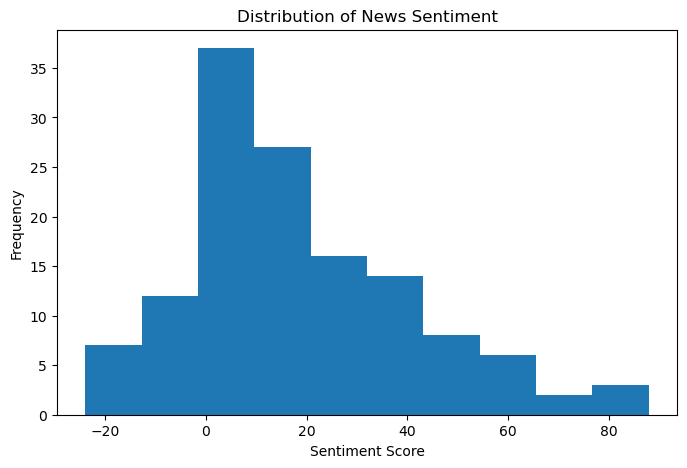

In [44]:
import matplotlib.pyplot as plt

# ---------- Histogram ----------

plt.figure(figsize=(8,5))

plt.hist(merged['sentiment_score'])

plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Distribution of News Sentiment")

plt.savefig(
    "plots/histogram.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

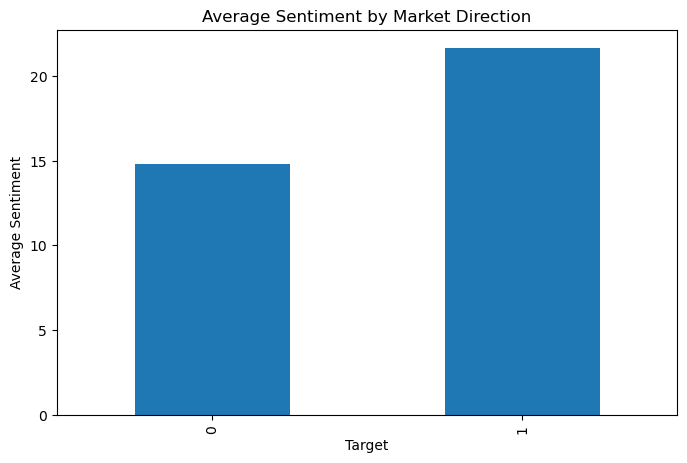

In [45]:
# ---------- Bar Plot ----------

plt.figure(figsize=(8,5))

merged.groupby('target')['sentiment_score'].mean().plot(
    kind='bar'
)

plt.xlabel("Target")
plt.ylabel("Average Sentiment")

plt.title(
    "Average Sentiment by Market Direction"
)

plt.savefig(
    "plots/barplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

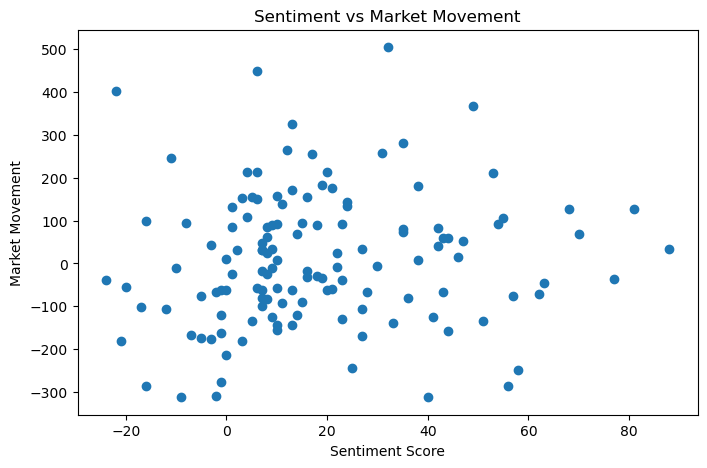

In [46]:

# ---------- Scatter Plot ----------

plt.figure(figsize=(8,5))

plt.scatter(
    merged['sentiment_score'],
    merged['movement']
)

plt.xlabel("Sentiment Score")
plt.ylabel("Market Movement")

plt.title(
    "Sentiment vs Market Movement"
)

plt.savefig(
    "plots/scatterplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [47]:
def predict_market(score):

    if score > 0:
        return "UP"

    elif score < 0:
        return "DOWN"

    else:
        return "NEUTRAL"

In [48]:
merged['prediction'] = merged[
    'sentiment_score'
].apply(predict_market)

print(
    merged[
        ['date',
         'sentiment_score',
         'prediction']
    ].head()
)

        date  sentiment_score prediction
0 2025-08-21                6         UP
1 2025-08-20                8         UP
2 2025-08-19                9         UP
3 2025-08-18               20         UP
4 2025-08-14                8         UP


In [49]:
def binary_prediction(score):

    if score > 0:
        return 1

    return 0

In [50]:
merged['prediction_binary'] = merged[
    'sentiment_score'
].apply(binary_prediction)

In [51]:
accuracy = (merged['prediction_binary']==merged['target']).mean()
print()
print("Prediction Accuracy:")
print(round(accuracy*100, 2),"%")


Prediction Accuracy:
59.85 %


In [52]:
merged.to_csv("final_project_dataset.csv", index=False) 
print("Final dataset saved successfully.")

Final dataset saved successfully.
